# Runge NCEP SLP 60 维可视化与非线性 causal gateway benchmark

目标：用一个最新的 12 维非线性人工系统检验 PEID 概率因果读出是否能识别设计好的 causal gateway，并保留真实 Runge-NCEP 60 维分量作为尺度、相关结构和可视化参照。旧的线性 `sparse_var12` sanity check 已从 notebook 中移除；可复用实现保留在 Python 模块和测试中。


In [1]:

from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "AGENTS.md").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from exp.runge_slp_60d_visualization.synthetic_runge_gru import (
    GruTrainingConfig,
    MlpTrainingConfig,
    SyntheticRungeConfig,
    load_component_scores,
    make_supervised_windows,
    metrics_table,
    plot_gateway_topology,
    plot_pairwise_causal_graph_triptych,
    plot_pairwise_recovery_triptych,
    plot_prediction_quality,
    plot_top_synergy_hypergraph,
    plot_training_history,
    run_gateway_synergy_benchmark,
    train_gru_forecaster,
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 9,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})

RESULT_DIR = ROOT / "results" / "runge2015_gateways"
DATA_DIR = ROOT / "data" / "ncep_reanalysis_slp"
FIG_DIR = ROOT / "fig" / "runge_slp_60d_visualization"
SAVE_FIGURES = False

WEEKLY_SCORES_PATH = RESULT_DIR / "component_weekly_scores.csv"
DAILY_SCORES_PATH = RESULT_DIR / "component_daily_scores.csv"
MAPS_PATH = RESULT_DIR / "component_maps.npz"
MANIFEST_PATH = RESULT_DIR / "manifest.json"

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)


## 真实 Runge-NCEP 60 维数据

真实参照来自已有 Runge 工作流缓存：对标准化 NCEP/NCAR 海平面气压异常做 Varimax 后得到的 weekly 分量 score。下面的合成系统不是新的气候重建，而是一个受控的非线性 sanity check：它与真实数据有相同分量数，并尽量保持相近的 score 尺度。


In [2]:

required = [WEEKLY_SCORES_PATH, DAILY_SCORES_PATH, MAPS_PATH, MANIFEST_PATH]
missing = [path for path in required if not path.exists()]
if missing:
    missing_text = "\n".join(str(path.relative_to(ROOT)) for path in missing)
    raise FileNotFoundError(
        "Missing Runge reduced-data cache(s):\n"
        f"{missing_text}\n\n"
        "Recompute them from the repo root with:\n"
        "python scripts/reproduce_runge2015_gateways.py --mode full --causal-backend tigramite"
    )

weekly_scores = load_component_scores(WEEKLY_SCORES_PATH)
daily_scores = load_component_scores(DAILY_SCORES_PATH)
with MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    manifest = json.load(handle)
with np.load(MAPS_PATH) as maps_npz:
    component_maps = maps_npz["component_maps"]
    explained_ratio = maps_npz["explained_variance_ratio"]

summary = pd.DataFrame([
    {
        "Dataset": "weekly_scores",
        "Rows": weekly_scores.shape[0],
        "Columns": weekly_scores.shape[1],
        "Start": weekly_scores.index.min(),
        "End": weekly_scores.index.max(),
    },
    {
        "Dataset": "daily_scores",
        "Rows": daily_scores.shape[0],
        "Columns": daily_scores.shape[1],
        "Start": daily_scores.index.min(),
        "End": daily_scores.index.max(),
    },
])
display(summary)
display(pd.Series(manifest.get("config", {}), name="value").to_frame())


,Dataset,Rows,Columns,Start,End
0,weekly_scores,3339,60,1948-01-01,2011-12-22
1,daily_scores,23376,60,1948-01-01,2011-12-31


,value
mode,full
data_dir,data/ncep_reanalysis_slp
output_dir,.
start_year,1948
end_year,2011
n_components,60
max_lag,4
pc_alpha,0.001
link_density,0.2
seed,42


## PEID causal role 指标

设一步干预读出得到 pairwise effective information 矩阵

$$E_{ij}=EI_{i\to j}=I_{do}(X_i;Y_j).$$

其中 $X_i$ 是源分量的最大熵干预状态，$Y_j$ 是模型预测的下一期目标分量。这里把 $E_{ij}$ 解释为概率因果强度：在统一干预分布下，源 $i$ 对目标 $j$ 的机制可区分性越高，$i\to j$ 的有向因果影响越强。去掉自环后，对 $\mathbf{E}$ 做行归一化得到 $\widetilde{\mathbf{E}}$，有限路径影响定义为

$$\mathbf{P}=\sum_{\ell=1}^{L}\gamma^{\ell-1}\widetilde{\mathbf{E}}^{\ell}.$$

其中 $L$ 是最大路径长度，$\gamma\in(0,1)$ 是长路径折扣。节点 $i$ 的 pairwise gateway reach 是

$$G_i^{pair}=\sum_j P_{ij}.$$

若人工系统有模块标签，还额外计算跨模块输出路径

$$G_i^{cross}=\sum_{j:m(j)\ne m(i)}P_{ij}.$$

二阶 PEID synergy 对源对 $\{i,k\}$ 到目标 $j$ 的联合因果贡献写为

$$\Delta_{\{i,k\}\to j}=EI_{\{i,k\}\to j}-EI_{i\to j}-EI_{k\to j}.$$

只把正 synergy 计入源侧协同贡献和目标侧协同贡献：

$$S_i^{src}=\sum_{k,j}\max(0,\Delta_{\{i,k\}\to j}),\qquad
S_i^{tgt}=\sum_{a,b}\max(0,\Delta_{\{a,b\}\to i}).$$

因此本 notebook 同时报告两个对照分数：

- `pairwise-only`：只使用 $G_i^{pair}+G_i^{cross}$ 和 pairwise path mediator；
- `synergy-aware`：在 pairwise 路径读数上加入 $S_i^{src}$ 与 $S_i^{tgt}$。

最终 gateway 分数与 mediator 分数为

$$\mathrm{Gateway}(i)=G_i^{pair}+G_i^{cross}+S_i^{src}.$$

$$\mathrm{Mediator}(i)=\left(\sum_j P_{ji}+S_i^{tgt}\right)\left(\sum_j P_{ij}\right).$$

这里的关键不是声称 synergy 一定推翻 pairwise 结论，而是检验 pairwise-only 是否漏掉一种关键节点：这个节点的单源传播可能已经可见，但它真正的系统角色来自和其他源共同驱动目标，或者作为二阶协同目标后继续向下游传播。



In [3]:
HISTORY_WEEKS = 4
PREDICT_HORIZON = 1
PEID_INTERVENTION_SAMPLES = 2048
PEID_BINS = 5

GATEWAY_SYNTHETIC_CONFIG = SyntheticRungeConfig(
    dynamics_kind="nonlinear_gateway_synergy12",
    n_components=12,
    n_steps=len(weekly_scores),
    burn_in=1000,
    lag=4,
    noise_scale=0.02,
    nonlinear_strength=0.18,
    synergy_strength=0.24,
    seed=52,
    apply_observation_mixing=False,
)

GATEWAY_GRU_CONFIG = GruTrainingConfig(
    hidden_dim=64,
    num_layers=1,
    epochs=80,
    batch_size=256,
    learning_rate=1.0e-3,
    weight_decay=1.0e-5,
    patience=20,
    train_fraction=0.70,
    val_fraction=0.15,
    seed=43,
)

GATEWAY_MLP_CONFIG = MlpTrainingConfig(
    hidden_dims=(128, 64),
    epochs=80,
    batch_size=256,
    learning_rate=1.0e-3,
    weight_decay=1.0e-5,
    patience=20,
    seed=45,
)


## 非线性 causal gateway 人工系统

人工系统保留 12 维机制坐标，并分成两个子模块：`component_01` 到 `component_06` 为模块 A，`component_07` 到 `component_12` 为模块 B。`component_01` 被设计为跨模块 causal gateway：它接收模块 A 内多个输入，并向模块 B 多个目标输出；二源协同项也主要让 `component_01` 作为联合源之一参与目标生成。


In [4]:
gateway_result = run_gateway_synergy_benchmark(
    synthetic_config=GATEWAY_SYNTHETIC_CONFIG,
    gru_config=GATEWAY_GRU_CONFIG,
    mlp_config=GATEWAY_MLP_CONFIG,
    history=HISTORY_WEEKS,
    horizon=PREDICT_HORIZON,
    intervention_samples=PEID_INTERVENTION_SAMPLES,
    bins=PEID_BINS,
)

for name, value in gateway_result.items():
    globals()[name] = value


In [5]:
display(gateway_metric_frame)
display(gateway_recovery_frame)
display(role_summary)
display(synergy_necessity_ablation)
display(gateway_truth_role_scores.head(6))
display(gateway_gru_role_scores.head(6))
display(gateway_mlp_role_scores.head(6))
display(gateway_topology_scores.head(6))
display(gateway_truth_synergy)



Model,GRU,MLP
Metric,,
Best validation loss,0.577498,0.599242
Persistence test NRMSE,0.984997,0.984997
Persistence test RMSE,0.770549,0.770549
RMSE improvement vs persistence,0.170255,0.158201
Test NRMSE,0.767359,0.782767
Test R2,0.408429,0.384434
Test RMSE,0.600295,0.612348
Training epochs,62.000000,40.000000


Estimator,GRU + discrete PEID,MLP + discrete PEID
top_k,38.000000,38.000000
ground_truth_edges,38.000000,38.000000
true_positive_edges,36.000000,36.000000
precision_at_k,0.947368,0.947368
recall_at_k,0.947368,0.947368


,component_01_gateway_rank,component_01_gateway_score,top_gateway
Estimator,,,
Ground-truth dynamics,1,3.908133,component_01
GRU + PEID,1,5.306822,component_01
MLP + PEID,1,4.146163,component_01


,pairwise_only_component_01_gateway_rank,synergy_aware_component_01_gateway_rank,pairwise_only_top_gateway,synergy_aware_top_gateway,synergy_aware_top_is_component_01,positive_synergy_edges_with_component_01,component_01_synergy_source_score,component_01_synergy_target_score
Estimator,,,,,,,,
Ground-truth dynamics,1,1,component_01,component_01,True,5,1.820000,0.000000
GRU + PEID,1,1,component_01,component_01,True,20,3.291540,0.247839
MLP + PEID,1,1,component_01,component_01,True,20,2.127078,0.241003


,component,source_index,module,direct_in_strength,direct_out_strength,incoming_path_effect,outgoing_path_effect,cross_module_direct_out_strength,cross_module_outgoing_path_effect,synergy_source_score,synergy_target_score,gateway_score,mediator_score,gateway_rank,mediator_rank
0,component_01,0,A,1.36,2.98,0.479003,1.044067,2.98,1.044067,1.82,0.00,3.908133,0.500111,1,1
1,component_03,2,A,0.17,0.66,0.058718,0.306941,0.00,0.075018,0.38,0.00,0.761959,0.018023,2,9
2,component_02,1,A,0.13,0.51,0.045060,0.259932,0.00,0.080192,0.42,0.00,0.760123,0.011713,3,12
3,component_06,5,A,0.14,0.52,0.050656,0.237852,0.00,0.052559,0.36,0.00,0.650410,0.012049,4,10
4,component_09,8,B,0.65,0.30,0.280490,0.103496,0.00,0.000000,0.32,0.34,0.423496,0.064219,5,3
5,component_07,6,B,0.70,0.15,0.303358,0.053897,0.00,0.000000,0.34,0.42,0.393897,0.038987,6,4


,component,source_index,module,direct_in_strength,direct_out_strength,incoming_path_effect,outgoing_path_effect,cross_module_direct_out_strength,cross_module_outgoing_path_effect,synergy_source_score,synergy_target_score,gateway_score,mediator_score,gateway_rank,mediator_rank
0,component_01,0,A,0.343015,3.281260,0.108286,1.012206,3.255623,1.003075e+00,3.291540,0.247839,5.306822,0.360471,1,1
1,component_03,2,A,0.173088,0.422562,0.054547,0.147297,0.000000,1.580258e-02,1.116956,0.437338,1.280055,0.072453,2,2
2,component_06,5,A,0.096631,0.315568,0.031446,0.108270,0.000000,8.995116e-03,0.919902,0.272109,1.037167,0.032866,3,5
3,component_09,8,B,0.496003,0.200050,0.162330,0.061034,0.000000,6.541594e-05,0.944998,0.614583,1.006097,0.047418,4,3
4,component_02,1,A,0.102317,0.265495,0.031820,0.108791,0.000000,2.381128e-02,0.848103,0.310254,0.980705,0.037215,5,4
5,component_08,7,B,0.695682,0.081847,0.227551,0.025297,0.000000,2.896484e-07,0.762269,0.576887,0.787566,0.020350,6,8


,component,source_index,module,direct_in_strength,direct_out_strength,incoming_path_effect,outgoing_path_effect,cross_module_direct_out_strength,cross_module_outgoing_path_effect,synergy_source_score,synergy_target_score,gateway_score,mediator_score,gateway_rank,mediator_rank
0,component_01,0,A,0.351018,3.551334,0.102096,1.012949,3.530673,1.006136e+00,2.127078,0.241003,4.146163,0.347542,1,1
1,component_03,2,A,0.146011,0.412361,0.042037,0.128461,0.000000,1.036988e-02,0.711270,0.251025,0.850101,0.037647,2,2
2,component_02,1,A,0.121140,0.271641,0.034515,0.103214,0.000000,2.341180e-02,0.572751,0.213157,0.699377,0.025563,3,4
3,component_09,8,B,0.606154,0.184359,0.182906,0.051949,0.000000,3.624413e-05,0.622477,0.434212,0.674462,0.032059,4,3
4,component_06,5,A,0.060699,0.320747,0.018209,0.102544,0.000000,9.416347e-03,0.498436,0.128534,0.610396,0.015048,5,8
5,component_08,7,B,0.710955,0.132453,0.213977,0.037851,0.000000,2.901199e-07,0.553735,0.363855,0.591587,0.021872,6,5


,rank,component,source_index,out_degree,cross_module_out_degree,direct_out_strength,path_effect
0,1,component_01,0,6.0,6.0,2.98,1.044067
1,2,component_03,2,3.0,0.0,0.66,0.306941
2,3,component_02,1,2.0,0.0,0.51,0.259932
3,4,component_06,5,3.0,0.0,0.52,0.237852
4,5,component_04,3,2.0,0.0,0.42,0.208428
5,6,component_05,4,2.0,0.0,0.37,0.183787


,source_i,source_j,target_index,sources,target,coefficient,edge_kind
0,0,1,6,component_01+component_02,component_07,0.42,gateway_synergy
1,0,2,7,component_01+component_03,component_08,-0.38,gateway_synergy
2,0,5,10,component_01+component_06,component_11,0.36,gateway_synergy
3,0,6,8,component_01+component_07,component_09,0.34,gateway_receiver_synergy
4,0,8,11,component_01+component_09,component_12,-0.32,gateway_receiver_synergy


`role_summary` 是本 notebook 的核心读数，`synergy_necessity_ablation` 是必要性对照。`Ground-truth dynamics` 应把 `component_01` 排为第 1 gateway；若 `GRU + PEID` 和 `MLP + PEID` 也把 `component_01` 排到前列，说明该指标不仅能在已知动力学上识别设计 gateway，也能从学好的神经网络转移机制中重新读出这一 causal role。

必要性判断看 `pairwise-only` 与 `synergy-aware` 的差异：如果加入正二阶 synergy 后 `component_01` 的 gateway rank 更靠前、top gateway 回到设计真值，或者 top positive synergy hyperedges 中多次包含 `component_01`，就说明关键节点识别不能只依赖单源 pairwise EI。Pairwise EI 识别的是单源传播强度；PEID synergy 补上的则是“只有联合源状态才能解释目标变化”的机制信息。



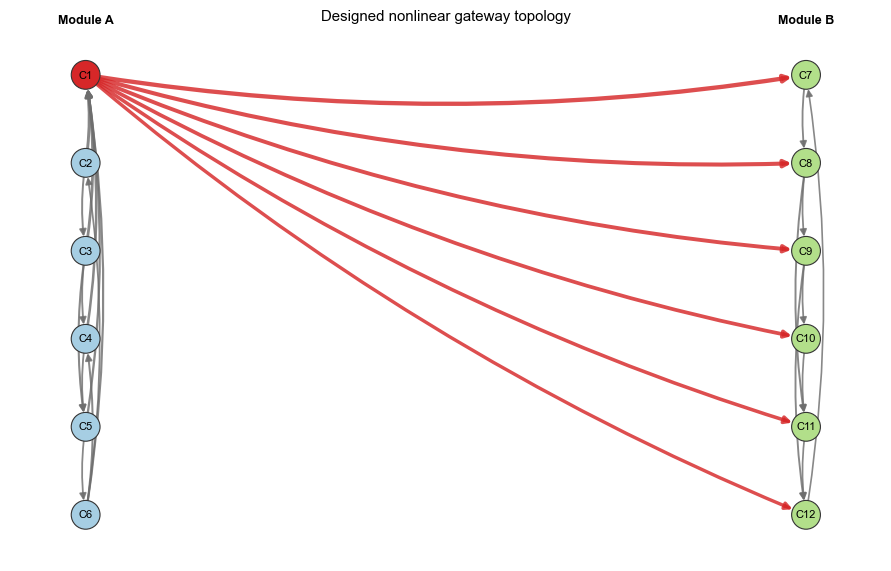

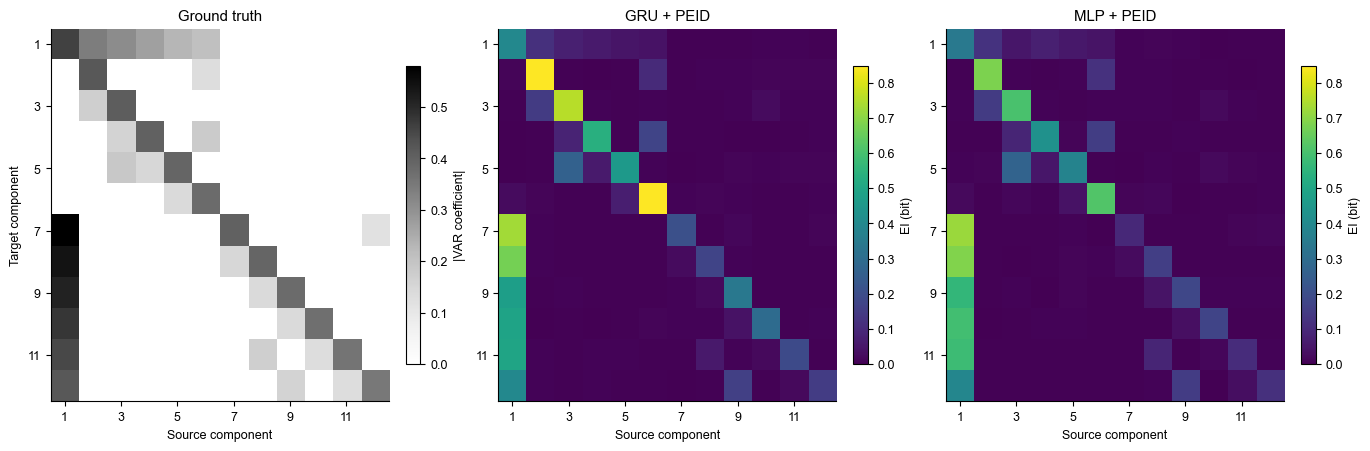

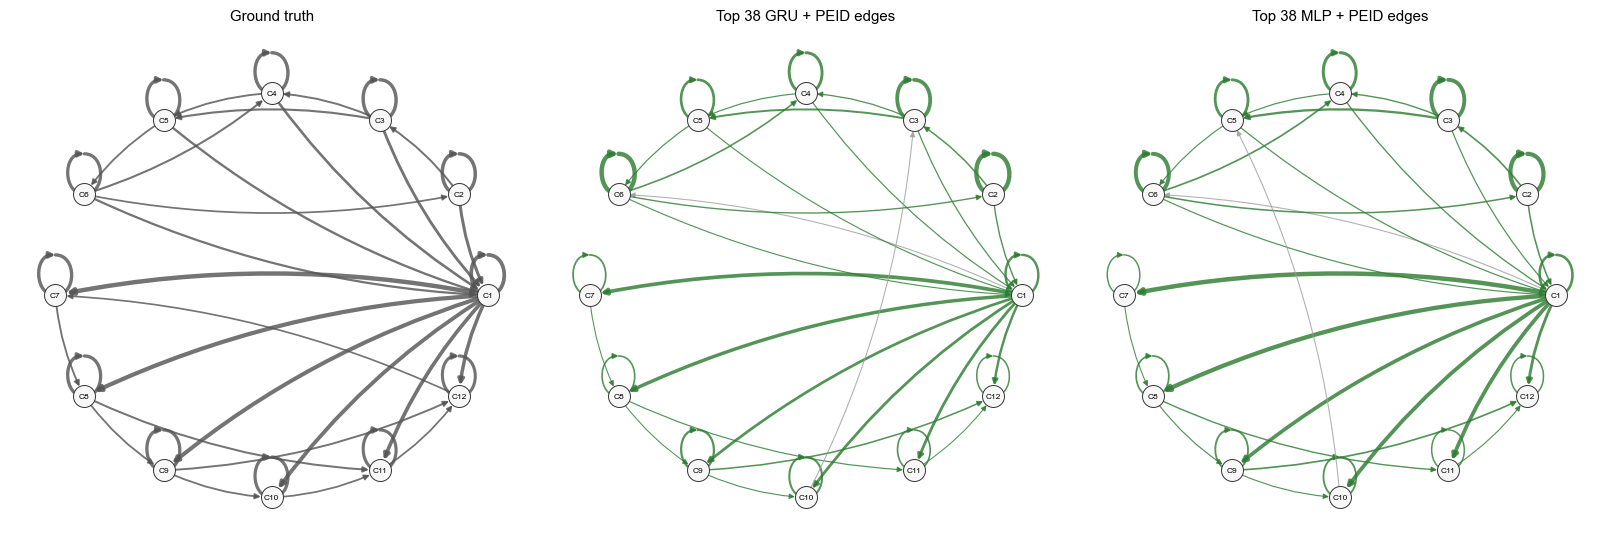

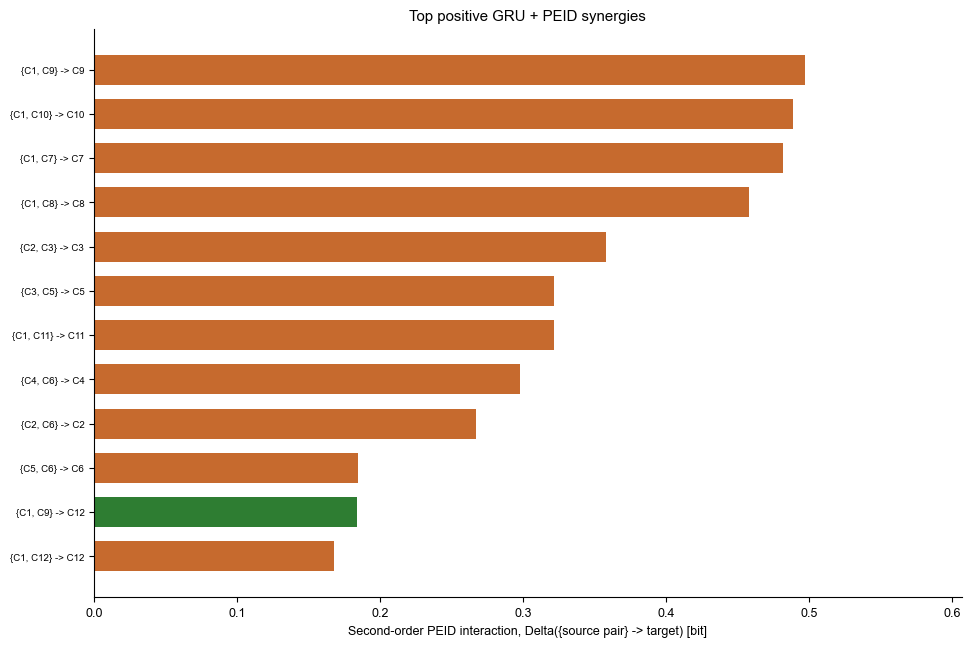

In [6]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig = plot_gateway_topology(gateway_metadata)
fig.savefig(FIG_DIR / "nonlinear_gateway_synergy12_ground_truth_topology.png", dpi=240, bbox_inches="tight")
plt.show()

fig = plot_pairwise_recovery_triptych(
    gateway_gru_peid["pairwise_matrix"],
    gateway_mlp_peid["pairwise_matrix"],
    gateway_truth_pairwise,
)
fig.savefig(FIG_DIR / "nonlinear_gateway_synergy12_gru_mlp_peid_triptych_heatmap.png", dpi=240, bbox_inches="tight")
plt.show()

fig = plot_pairwise_causal_graph_triptych(
    gateway_gru_peid["pairwise_edges"],
    gateway_mlp_peid["pairwise_edges"],
    gateway_truth_pairwise,
    top_k=top_graph_edges,
    n_components=GATEWAY_SYNTHETIC_CONFIG.n_components,
    seed=GATEWAY_GRU_CONFIG.seed + 100,
)
fig.savefig(FIG_DIR / "nonlinear_gateway_synergy12_ground_truth_gru_mlp_peid_causal_graphs.png", dpi=240, bbox_inches="tight")
plt.show()

fig = plot_top_synergy_hypergraph(
    gateway_gru_peid["synergy_edges"],
    gateway_truth_synergy,
    top_k=12,
    p_threshold=1.0,
)
fig.savefig(FIG_DIR / "nonlinear_gateway_synergy12_gru_peid_synergy_hyperedges.png", dpi=240, bbox_inches="tight")
plt.show()


拓扑图展示的是人工系统的设计真值；三联图比较 ground truth、GRU+PEID 与 MLP+PEID 的 pairwise 因果边恢复；synergy 图检查以 `component_01` 为联合源的二阶协同项是否在 learned PEID 中保留协同贡献。图像均保存为 PNG，便于 notebook、Markdown 和聊天摘要直接查看。


## Synergy necessity 与真实 Runge 参照

上面的人工系统有已知真值，因此适合回答“是否需要 synergy 才能识别设计好的关键节点”。真实 Runge-NCEP 分量没有可直接验证的 ground-truth gateway，但已有 Runge 结果整理显示：pairwise MLP-TM-EI gateway 与 PEID Hyper-ACE 的排序并不只是数值重标定。PEID 与 pairwise baseline 的 gateway 排序 Spearman 相关为 0.7663，top-5 gateway 只有 No.0 重合；top-10 中则保留 No.0、No.18、No.12、No.13、No.15、No.7、No.24 等共同候选。

因此真实数据部分只作为应用参照：synergy-aware 排序不会自动推翻 pairwise 传播结构，但它会改变哪些节点被优先解释为关键 gateway，尤其会突出作为二阶联合源成员参与目标变化的节点。这个差异正是后续把 PEID 超图用于关键节点识别的实验动机。



## 真实 Runge-NCEP 上复用同一组训练参数

这里不重新调参，直接把 gateway benchmark 里的 `GATEWAY_GRU_CONFIG`、四周历史窗口和一步预测目标套到真实 weekly score 上。目标不是证明真实气候过程同样容易预测，而是先看同一套训练设置在真实数据上的 loss 是否稳定、是否有类似的平滑下降趋势。


In [7]:

real_windows = make_supervised_windows(weekly_scores, history=HISTORY_WEEKS, horizon=PREDICT_HORIZON)
real_gru_result = train_gru_forecaster(real_windows, GATEWAY_GRU_CONFIG)

display(real_gru_result.split_summary.rename(columns={"split": "Split", "samples": "Samples", "start": "Start", "end": "End"}))
display(metrics_table(real_gru_result))


,Split,Samples,Start,End
0,train,2334,1948-01-29,1992-10-15
1,val,500,1992-10-22,2002-05-16
2,test,501,2002-05-23,2011-12-22


,Metric,Value
0,Test RMSE,0.729307
1,Test NRMSE,0.907094
2,Test R2,0.154473
3,Persistence test RMSE,0.920618
4,Persistence test NRMSE,1.145041
5,RMSE improvement vs persistence,0.191311
6,Best validation loss,0.861940
7,Training epochs,54.000000


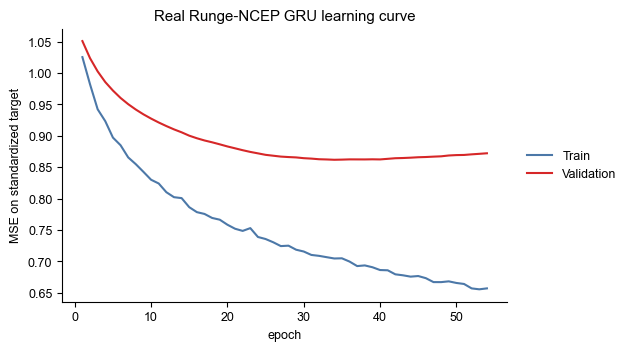

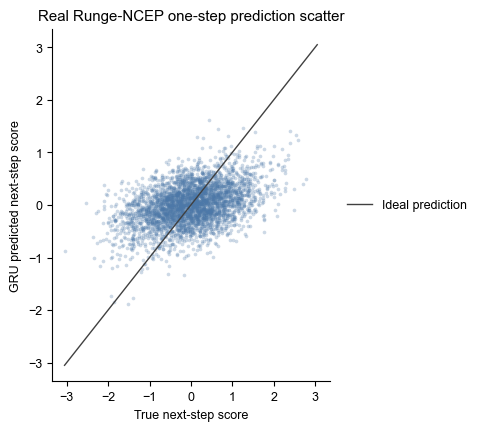

In [8]:

FIG_DIR.mkdir(parents=True, exist_ok=True)

fig = plot_training_history(real_gru_result)
fig.axes[0].set_title("Real Runge-NCEP GRU learning curve")
fig.savefig(FIG_DIR / "real_gru_learning_curve.png", dpi=220, bbox_inches="tight")
plt.show()

fig = plot_prediction_quality(real_gru_result, seed=GATEWAY_GRU_CONFIG.seed)
fig.axes[0].set_title("Real Runge-NCEP one-step prediction scatter")
fig.savefig(FIG_DIR / "real_gru_prediction_scatter.png", dpi=220, bbox_inches="tight")
plt.show()


真实数据训练曲线和预测散点图会直接保存到 `fig/runge/slp_60d_visualization/`。这次同参运行里，训练 loss 呈现平滑下降；验证 loss 前半段也平滑下降，但在达到最低点后缓慢回升并触发早停。因此真实数据没有完全复现合成动力学那种验证 loss 持续下降的形态，更合理的解释是 weekly score 的噪声、更弱可预测结构和时段分布差异更强，而不是训练代码本身的问题。


## 真实 Runge-NCEP 60 维参照图

后面的图用于真实降维数据上的人工神经网络调参。训练前可以先检查分量尺度、长期条带、分量相关结构和空间载荷形态，再决定模型容量、正则化强度和历史窗口长度。


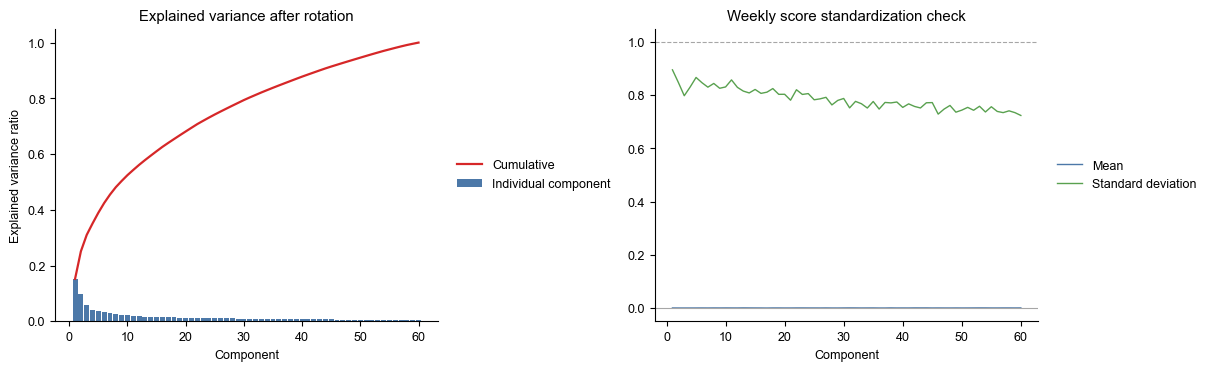

,Mean,Standard deviation,Minimum,Maximum
component_01,-0.000035,0.895266,-3.266956,3.626078
component_02,-0.000126,0.847939,-3.195898,2.666759
component_03,-0.000139,0.797880,-2.829715,2.550262
component_04,-0.000130,0.830704,-3.405296,3.130384
component_05,-0.000087,0.866620,-3.383561,2.774844
component_06,0.000021,0.846828,-2.669739,2.884157
component_07,-0.000079,0.830116,-3.113621,2.698832
component_08,0.000090,0.844067,-2.800162,3.074060
component_09,0.000003,0.825925,-3.321901,2.534338
component_10,0.000122,0.830969,-3.262399,2.660603


In [9]:

component_index = np.arange(1, len(explained_ratio) + 1)
score_stats = weekly_scores.describe().T[["mean", "std", "min", "max"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
axes[0].bar(component_index, explained_ratio, color="#4C78A8", width=0.85, label="Individual component")
axes[0].plot(component_index, np.cumsum(explained_ratio), color="#D62728", lw=1.6, label="Cumulative")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Explained variance after rotation")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

axes[1].plot(component_index, score_stats["mean"], color="#4C78A8", lw=1.0, label="Mean")
axes[1].plot(component_index, score_stats["std"], color="#59A14F", lw=1.0, label="Standard deviation")
axes[1].axhline(0.0, color="0.65", lw=0.8)
axes[1].axhline(1.0, color="0.65", lw=0.8, ls="--")
axes[1].set_xlabel("Component")
axes[1].set_title("Weekly score standardization check")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "variance_and_scale.png", dpi=220, bbox_inches="tight")
plt.show()

display(score_stats.rename(columns={"mean": "Mean", "std": "Standard deviation", "min": "Minimum", "max": "Maximum"}).head(10))


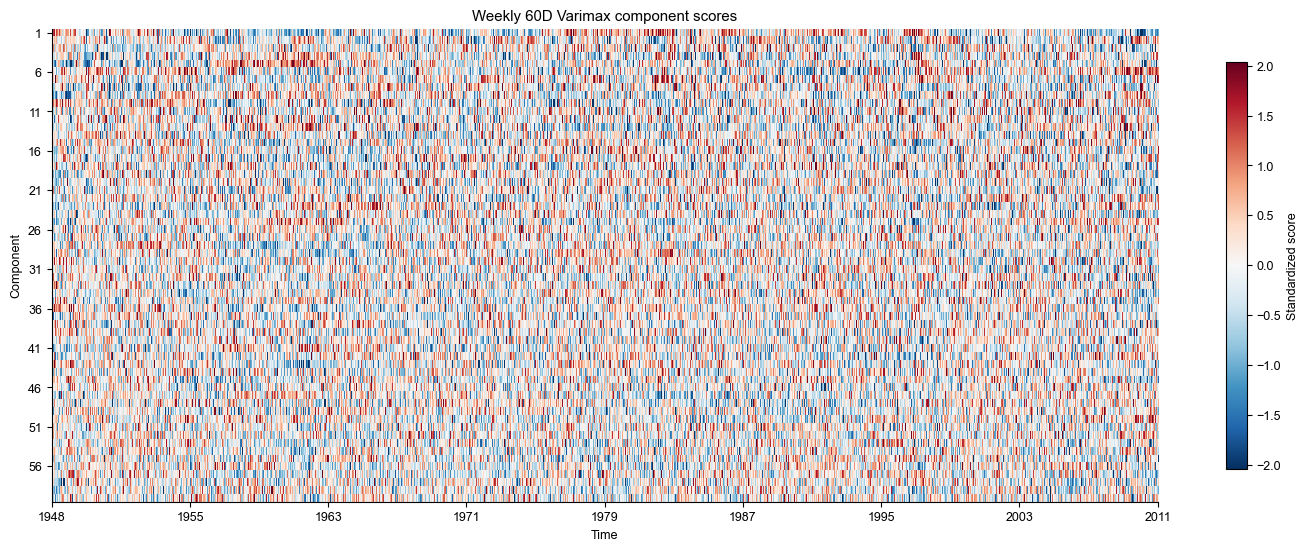

In [10]:

values = weekly_scores.to_numpy(dtype=float).T
vlim = float(np.nanpercentile(np.abs(values), 99.0))
fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
im = ax.imshow(values, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-vlim, vmax=vlim)
ax.set_yticks(np.arange(0, weekly_scores.shape[1], 5))
ax.set_yticklabels(np.arange(1, weekly_scores.shape[1] + 1, 5))
xticks = np.linspace(0, len(weekly_scores) - 1, 9, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels([weekly_scores.index[i].strftime("%Y") for i in xticks], rotation=0)
ax.set_xlabel("Time")
ax.set_ylabel("Component")
ax.set_title("Weekly 60D Varimax component scores")
fig.colorbar(im, ax=ax, label="Standardized score", shrink=0.86)

if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "weekly_60d_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()


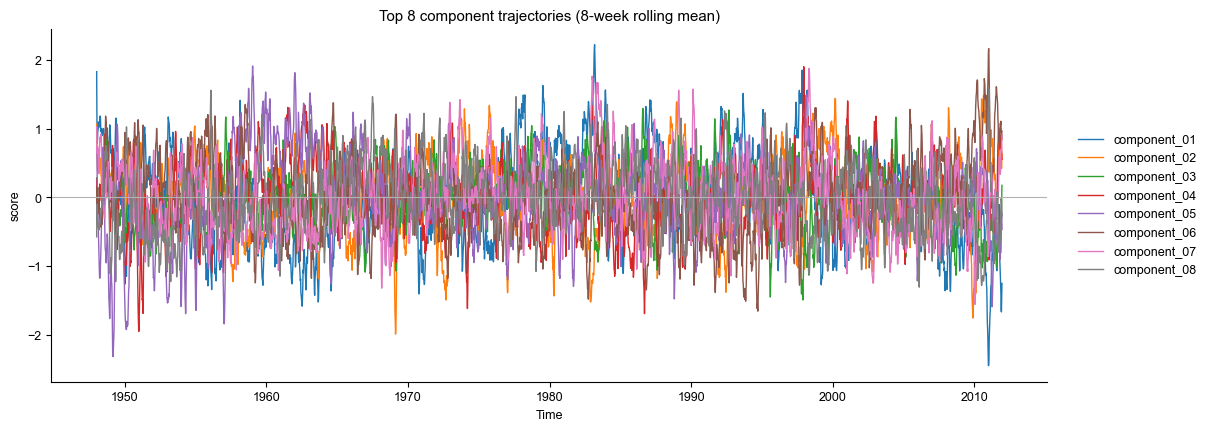

In [11]:

TOP_K = 8
SELECTED_COMPONENTS = list(np.argsort(explained_ratio)[::-1][:TOP_K] + 1)
ROLLING_WEEKS = 8
selected_cols = [f"component_{idx:02d}" for idx in SELECTED_COMPONENTS]
plot_frame = weekly_scores[selected_cols].rolling(ROLLING_WEEKS, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
for col in selected_cols:
    ax.plot(plot_frame.index, plot_frame[col], lw=1.0, label=col)
ax.axhline(0.0, color="0.7", lw=0.8)
ax.set_title(f"Top {TOP_K} component trajectories ({ROLLING_WEEKS}-week rolling mean)")
ax.set_xlabel("Time")
ax.set_ylabel("score")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "top_component_traces.png", dpi=220, bbox_inches="tight")
plt.show()


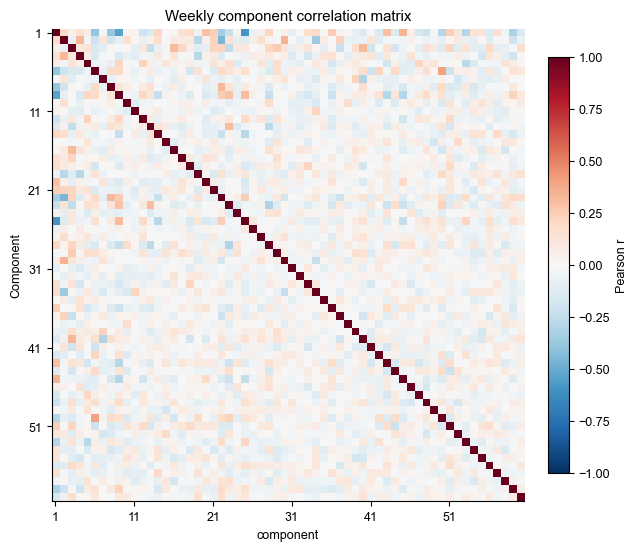

In [12]:

corr = weekly_scores.corr()
fig, ax = plt.subplots(figsize=(6.3, 5.4), constrained_layout=True)
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
ax.set_xticks(np.arange(0, weekly_scores.shape[1], 10))
ax.set_yticks(np.arange(0, weekly_scores.shape[1], 10))
ax.set_xticklabels(np.arange(1, weekly_scores.shape[1] + 1, 10))
ax.set_yticklabels(np.arange(1, weekly_scores.shape[1] + 1, 10))
ax.set_xlabel("component")
ax.set_ylabel("Component")
ax.set_title("Weekly component correlation matrix")
fig.colorbar(im, ax=ax, label="Pearson r", shrink=0.88)

if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "weekly_component_correlation.png", dpi=220, bbox_inches="tight")
plt.show()


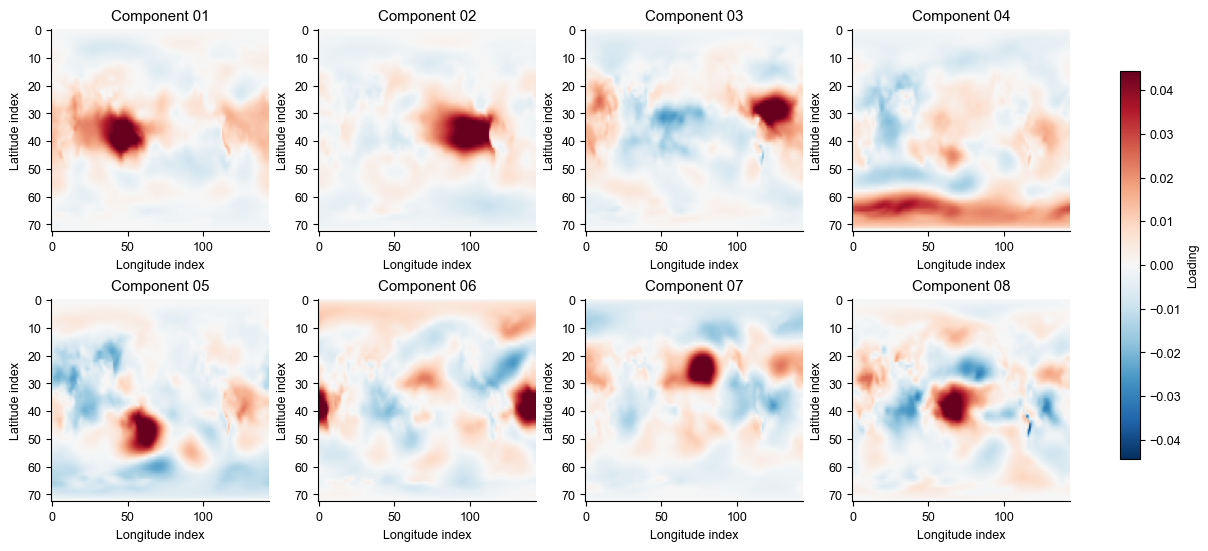

In [13]:

MAP_COMPONENTS = SELECTED_COMPONENTS[:8]
n_cols = 4
n_rows = int(np.ceil(len(MAP_COMPONENTS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.7 * n_rows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
map_vlim = float(np.nanpercentile(np.abs(component_maps[:, :, np.array(MAP_COMPONENTS) - 1]), 99.0))

for ax, comp in zip(axes, MAP_COMPONENTS):
    img = component_maps[:, :, comp - 1]
    im = ax.imshow(img, cmap="RdBu_r", vmin=-map_vlim, vmax=map_vlim, aspect="auto")
    ax.set_title(f"Component {comp:02d}")
    ax.set_xlabel("Longitude index")
    ax.set_ylabel("Latitude index")
for ax in axes[len(MAP_COMPONENTS):]:
    ax.axis("off")
fig.colorbar(im, ax=axes[:len(MAP_COMPONENTS)], label="Loading", shrink=0.82)

if SAVE_FIGURES:
    fig.savefig(FIG_DIR / "selected_component_maps.png", dpi=220, bbox_inches="tight")
plt.show()


## 手动调参备注

- 真实 NCEP 60 维图只用于诊断真实数据尺度、相关结构和空间载荷，不应被解释为有已知 ground truth 的因果恢复实验。
